Loss: 0.1360, Accuracy: 1.0000
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step


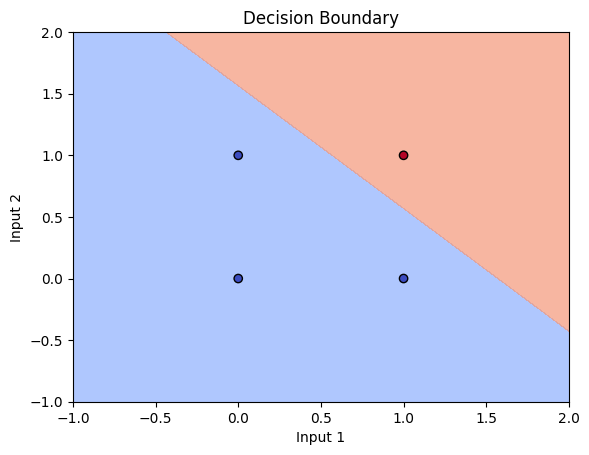

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
labels = np.array([[0], [0], [0], [1]], dtype=np.float32)
model = Sequential([Dense(units=1, activation='sigmoid', input_shape=(2,))])

model.compile(optimizer=SGD(learning_rate=0.1),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(data, labels, epochs=1000, verbose=0)

loss, accuracy = model.evaluate(data, labels, verbose=0)
print(f'Loss: {loss:.4f}, Accuracy: {accuracy:.4f}')

def plot_decision_boundary(model, data, labels):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max,100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, predictions, alpha=0.7, levels=[0, 0.5, 1], cmap="coolwarm")
    plt.scatter(data[:, 0], data[:, 1], c=labels[:, 0], edgecolors='k', cmap="coolwarm")
    plt.title("Decision Boundary")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()
plot_decision_boundary(model, data, labels)    

Epoch 1/50


C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9265 - loss: 0.2488 - val_accuracy: 0.9561 - val_loss: 0.1550
Epoch 2/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9690 - loss: 0.1026 - val_accuracy: 0.9629 - val_loss: 0.1211
Epoch 3/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9785 - loss: 0.0677 - val_accuracy: 0.9593 - val_loss: 0.1445
Epoch 4/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9842 - loss: 0.0539 - val_accuracy: 0.9626 - val_loss: 0.1780
Epoch 5/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9856 - loss: 0.0467 - val_accuracy: 0.9663 - val_loss: 0.1610
Epoch 6/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0354 - val_accuracy: 0.9682 - val_loss: 0.1538
Epoch 7/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9912 - loss: 0.0259 - val_accuracy: 0.9683 - val_loss: 0.1940
Epoch 8/50
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9920 - loss: 0.0273 - val_accurac

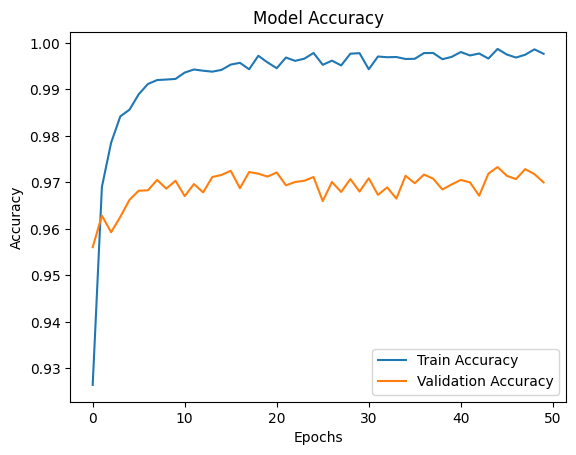

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Sample 1
True Label: 8
Predicted Label: 8

Sample 2
True Label: 4
Predicted Label: 4

Sample 3
True Label: 8
Predicted Label: 8

Sample 4
True Label: 7
Predicted Label: 7

Sample 5
True Label: 7
Predicted Label: 7



In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
# Load MNIST dataset from Keras
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Combine train and test data
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Flatten 28x28 images into 784 features
X = X.reshape(X.shape[0], -1)

# One-hot encoding
y = tf.keras.utils.to_categorical(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model = tf.keras.Sequential([
    Dense(128,activation='relu',input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit( X_train,y_train,epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Visualize predictions
def visualize_predictions(model, X_test, y_test, num_samples=5):
    predictions = model.predict(X_test)

    y_pred = np.argmax(predictions, axis=1)
    y_test = np.argmax(y_test, axis=1)

    for i in range(num_samples):
        print(f"Sample {i+1}")
        print(f"True Label: {y_test[i]}")
        print(f"Predicted Label: {y_pred[i]}")
        print()

visualize_predictions(model, X_test, y_test)


Training model with sigmoid activation function...
Epoch 1/10


C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9015 - loss: 0.3848 - val_accuracy: 0.9391 - val_loss: 0.2060
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9546 - loss: 0.1565 - val_accuracy: 0.9538 - val_loss: 0.1597
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9699 - loss: 0.1048 - val_accuracy: 0.9594 - val_loss: 0.1358
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9797 - loss: 0.0721 - val_accuracy: 0.9640 - val_loss: 0.1257
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9856 - loss: 0.0517 - val_accuracy: 0.9636 - val_loss: 0.1213
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9911 - loss: 0.0357 - val_accuracy: 0.9669 - val_loss: 0.1192
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9938 - loss: 0.0256 - val_accuracy: 0.9632 - val_loss: 0.1297
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9957 - loss: 0.0186 - val_accurac

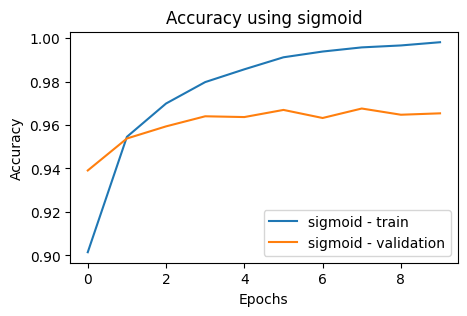

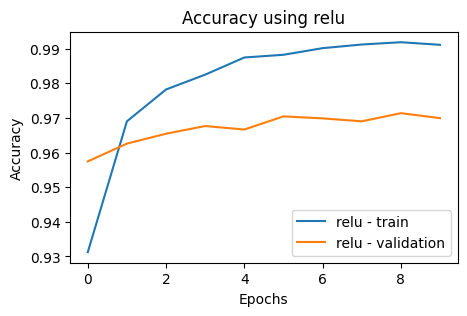

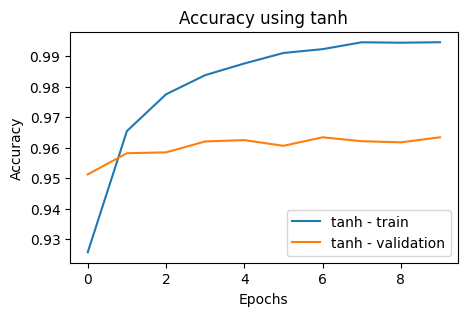

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Load MNIST dataset from Keras
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Combine train and test sets to mimic the CSV dataset
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Flatten 28x28 images into 784 features
X = X.reshape(X.shape[0], 784)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Function to create model
def create_model(activation_function):
    model = Sequential([
        Dense(128, input_shape=(X_train.shape[1],),
              activation=activation_function),
        Dense(64, activation=activation_function),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Activation functions to compare
activation_functions = ['sigmoid', 'relu', 'tanh']
results = {}

# Train models
for activation in activation_functions:
    print(f"\nTraining model with {activation} activation function...")

    model = create_model(activation)

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    results[activation] = history

# Plot results
for activation in activation_functions:
    plt.figure(figsize=(5, 3))

    history = results[activation]

    plt.plot(history.history['accuracy'],
             label=f'{activation} - train')
    plt.plot(history.history['val_accuracy'],
             label=f'{activation} - validation')

    plt.title(f'Accuracy using {activation}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

plt.show()

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3340 - loss: 1.8682 - val_accuracy: 0.4048 - val_loss: 1.6633
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4555 - loss: 1.5302 - val_accuracy: 0.4920 - val_loss: 1.4221
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5177 - loss: 1.3656 - val_accuracy: 0.5377 - val_loss: 1.3158
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5580 - loss: 1.2604 - val_accuracy: 0.5563 - val_loss: 1.2576
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5857 - loss: 1.1863 - val_accuracy: 0.5691 - val_loss: 1.2064
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6072 - loss: 1.1269 - val_accuracy: 0.5940 - val_loss: 1.1586
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6254 - loss: 1.0751 - val_accuracy: 0.6055 - val_loss: 1.1312
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6432 - loss: 1.0264 - 

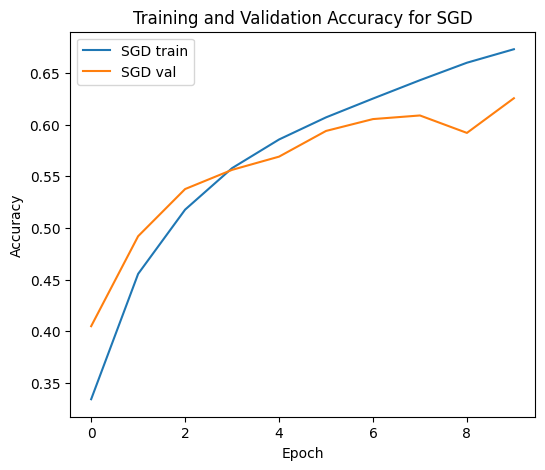

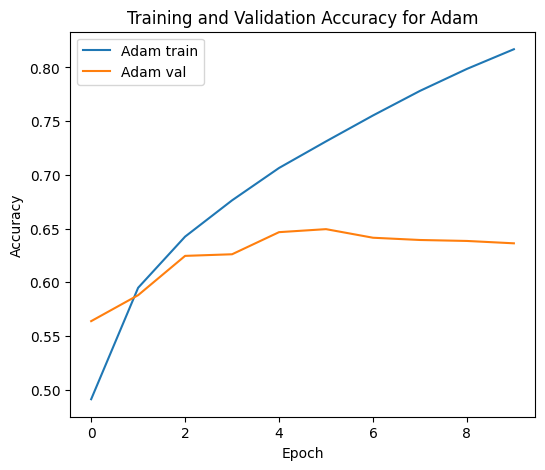

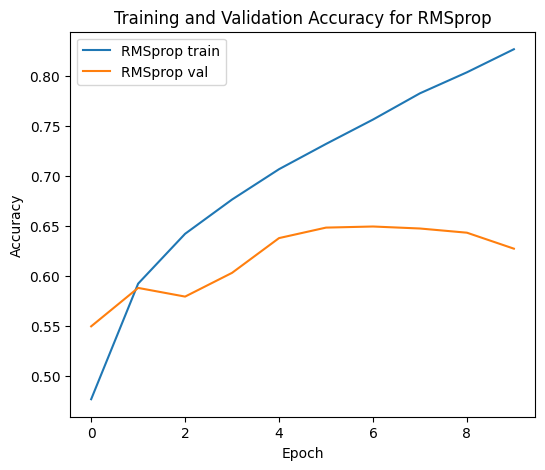

SGD - Train Accuracy: 0.6732, Validation Accuracy:0.6257
Adam - Train Accuracy: 0.8170, Validation Accuracy:0.6362
RMSprop - Train Accuracy: 0.8269, Validation Accuracy:0.6271


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0  


def build_and_train_model(optimizer, epochs=10):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())   
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1,validation_data=(X_test, y_test))
    return history     

optimizers = {'SGD': SGD(), 'Adam': Adam(), 'RMSprop': RMSprop()}
histories = {name: build_and_train_model(optimizer) for name, optimizer in optimizers.items()}
for name in optimizers.keys():
    plt.figure(figsize=(6, 5))
    plt.plot(histories[name].history['accuracy'], label=f'{name} train')
    plt.plot(histories[name].history['val_accuracy'], label=f'{name} val')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'Training and Validation Accuracy for {name}')
    plt.show()
for name, history in histories.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{name} - Train Accuracy: {final_train_acc:.4f}, Validation Accuracy:{final_val_acc:.4f}")    

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7528 - loss: 0.7379 - val_accuracy: 0.8340 - val_loss: 0.5129
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8133 - loss: 0.5772 - val_accuracy: 0.8488 - val_loss: 0.4787
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8230 - loss: 0.5519 - val_accuracy: 0.8452 - val_loss: 0.4839
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8322 - loss: 0.5346 - val_accuracy: 0.8504 - val_loss: 0.4736
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8375 - loss: 0.5206 - val_accuracy: 0.8525 - val_loss: 0.4639
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8395 - loss: 0.5162 - val_accuracy: 0.8537 - val_loss: 0.4682
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8422 - loss: 0.5130 - val_accuracy: 0.8531 - val_loss: 0.4661
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8394 - loss: 0.5151 - 

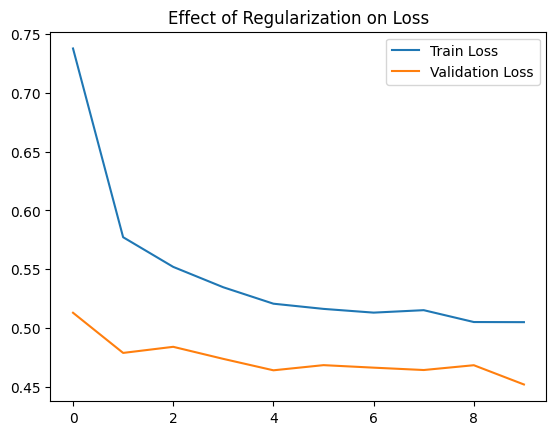

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Sequential
# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256,activation='relu',kernel_regularizer=keras.regularizers.l2(1e-4)),
    Dropout(0.5),
    Dense(128,activation='relu',kernel_regularizer=keras.regularizers.l2(1e-4)),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train,y_train,epochs=10,validation_data=(x_test, y_test))

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Effect of Regularization on Loss')
plt.show()


Starting Training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9570 - loss: 0.1413 - val_accuracy: 0.9874 - val_loss: 0.0418
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9859 - loss: 0.0455 - val_accuracy: 0.9885 - val_loss: 0.0354
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9899 - loss: 0.0320 - val_accuracy: 0.9893 - val_loss: 0.0328
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9924 - loss: 0.0234 - val_accuracy: 0.9909 - val_loss: 0.0305
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9941 - loss: 0.0187 - val_accuracy: 0.9900 - val_loss: 0.0314

Evaluating...
Test Accuracy: 0.9900
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


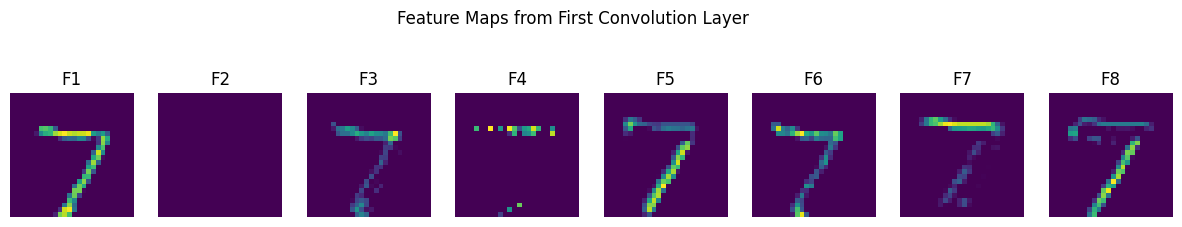

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import layers
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# CNN Model
model = keras.Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
print("\nStarting Training...")
model.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test, y_test))

# Evaluate model
print("\nEvaluating...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Create activation model for Conv2D layers
layer_outputs = [
    layer.output for layer in model.layers
    if isinstance(layer, layers.Conv2D)
]
activation_model = keras.Model(
    inputs=model.inputs,
    outputs=layer_outputs
)
# Select a test image
img = X_test[0].reshape(1, 28, 28, 1)

# Predict activations
activations = activation_model.predict(img)

# Visualize first Conv layer feature maps
first_layer_activations = activations[0]

num_filters = 8
fig, axes = plt.subplots(1, num_filters, figsize=(15, 3))

for i in range(num_filters):
    axes[i].imshow(
        first_layer_activations[0, :, :, i],
        cmap='viridis'
    )
    axes[i].axis('off')
    axes[i].set_title(f'F{i+1}')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()

C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Starting training...
Training Complete.


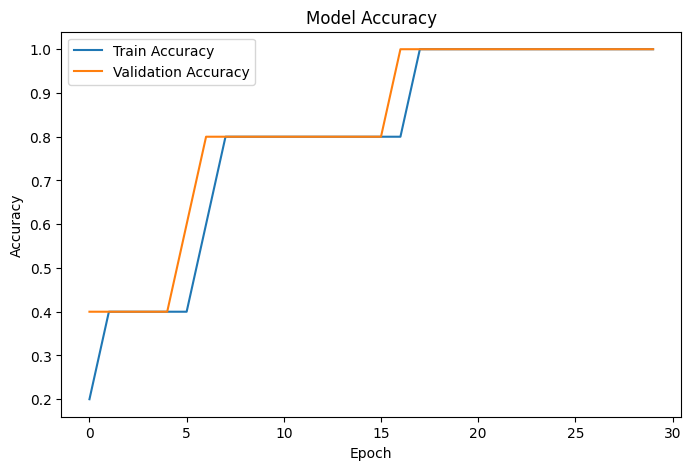


Predictions:
Text: The movie was bad bad bad, I will not recommend this movie to anyone
Result: Neutral Sentiment


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences, to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding

url1="https://raw.githubusercontent.com/iamsanjayashok/a/main/7train.csv"
url2="https://raw.githubusercontent.com/iamsanjayashok/a/main/7test.csv"

train_ds = pd.read_csv(url1, encoding='latin1')
validation_ds = pd.read_csv(url2, encoding='latin1')

train_ds = train_ds[['text', 'sentiment']]
validation_ds = validation_ds[['text', 'sentiment']]
train_ds['text'] = train_ds['text'].fillna('')
validation_ds['text'] = validation_ds['text'].fillna('')

def func(sentiment):
    if sentiment == 'positive':
        return 0
    elif sentiment == 'negative':
        return 1
    else:
        return 2

train_ds['sentiment'] = train_ds['sentiment'].apply(func)
validation_ds['sentiment'] = validation_ds['sentiment'].apply(func)

x_train = np.array(train_ds['text'].tolist())
y_train = to_categorical(np.array(train_ds['sentiment'].tolist()), 3)
x_test = np.array(validation_ds['text'].tolist())
y_test = to_categorical(np.array(validation_ds['sentiment'].tolist()), 3)


tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_padded = pad_sequences(x_train_seq, padding='post', maxlen=35)
x_test_padded = pad_sequences(x_test_seq, padding='post', maxlen=35)


model = Sequential()
# output_dim=8 (slightly higher to capture more nuance)
model.add(Embedding(input_dim=20000, output_dim=8, input_length=35))
model.add(SimpleRNN(32, return_sequences=False))
model.add(Dense(3, activation='softmax'))


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nStarting training...")
history = model.fit(x_train_padded, y_train, epochs=30, validation_data=(x_test_padded, y_test), verbose=0)
print("Training Complete.")

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

def predict_sentiment(text):
    new_text_seq = tokenizer.texts_to_sequences([text])
    new_text_padded = pad_sequences(new_text_seq, padding='post', maxlen=35)
    predictions = model.predict(new_text_padded, verbose=0)
    predicted_class_index = predictions.argmax(axis=-1)[0]
    
    if predicted_class_index == 0:
        return "Positive Sentiment"
    elif predicted_class_index == 1:
        return "Negative Sentiment"
    else:
        return "Neutral Sentiment"

print("\nPredictions:")
test_1 = "The movie was bad bad bad, I will not recommend this movie to anyone"
print(f"Text: {test_1}\nResult: {predict_sentiment(test_1)}")

mapping = {'positive': 0, 'negative': 1, 'neutral': 2}

In [5]:
test_1 = "nice movie"
print(f"Text: {test_1}\nResult: {predict_sentiment(test_1)}")

mapping = {'positive': 0, 'negative': 1, 'neutral': 2}

Text: nice movie
Result: Positive Sentiment


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.6592 - loss: 0.5977 - val_accuracy: 0.8003 - val_loss: 0.4401
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8464 - loss: 0.3521 - val_accuracy: 0.8298 - val_loss: 0.3986
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9026 - loss: 0.2381 - val_accuracy: 0.8300 - val_loss: 0.4154
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9282 - loss: 0.1857 - val_accuracy: 0.8169 - val_loss: 0.4959
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9466 - loss: 0.1378 - val_accuracy: 0.8216 - val_loss: 0.5296
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8216 - loss: 0.5296
Test Accuracy: 0.8216400146484375


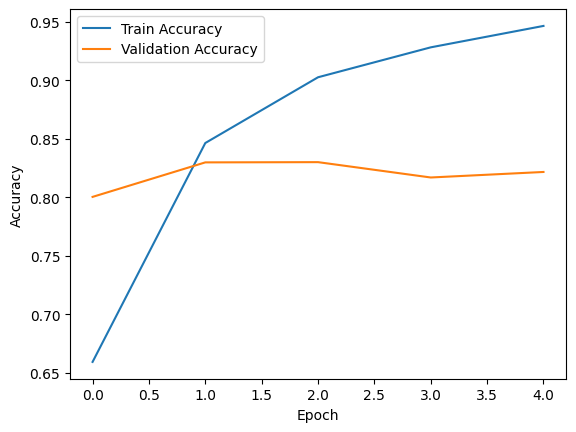

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Negative Review


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import numpy as np

# Load IMDB Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

# Pad Sequences
X_train = pad_sequences(X_train, maxlen=100)
X_test = pad_sequences(X_test, maxlen=100)

# Build RNN Model
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    SimpleRNN(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Sample Prediction
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

In [15]:
from tensorflow.keras.utils import pad_sequences
import tensorflow as tf

word_index = tf.keras.datasets.imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []

    for word in words:
        if word in word_index:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)  # unknown word

    return pad_sequences([encoded], maxlen=100)
sample=encode_review("movie was good")
pred=model.predict(sample)
if pred>0.5:
    print("Positive")
else:
    print("negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Positive


In [9]:
import tensorflow as tf

url = "https://huggingface.co/iamsanjayashok/flw/resolve/main/flowers.zip"

zip_path = tf.keras.utils.get_file(
    fname="flowers.zip",
    origin=url,
    extract=True
)

print(zip_path)

C:\Users\Sanjay A\.keras\datasets\flowers_extracted


In [10]:
base_path = r"C:\Users\Sanjay A\.keras\datasets\flowers_extracted\flowers (1)"

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total images loaded: 4331
95/95 ━━━━━━━━━━━━━━━━━━━━ 662s 7s/step - accuracy: 0.3002 - loss: 1.6575 - val_accuracy: 0.4031 - val_loss: 1.4286
136/136 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.3955 - loss: 1.4200
Loss: 1.4200257062911987
Accuracy: 0.3955206573009491
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 860ms/step


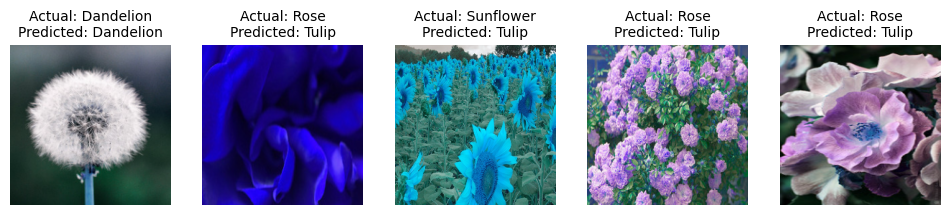

In [19]:
import numpy as np
import pandas as pd
import os
import glob
import cv2
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

base_path = r"C:\Users\Sanjay A\Desktop\shortcuts\dl\flowers"

print(os.listdir(base_path))

folders = glob.glob(base_path + "/*")

imagenames_list = []
for folder in folders:
    for f in glob.glob(folder + '/*.jpg'):
        imagenames_list.append(f)


def label_img(image):
    word_label = os.path.basename(os.path.dirname(image))
    if word_label == 'daisy':
        return [1,0,0,0,0]
    elif word_label == 'dandelion':
        return [0,1,0,0,0]
    elif word_label == 'rose':
        return [0,0,1,0,0]
    elif word_label == 'tulip':
        return [0,0,0,1,0]
    else:
        return [0,0,0,0,1]

train = []
for image in imagenames_list:
    img = cv2.imread(image)

    if img is None:
        continue

    img = cv2.resize(img, (224,224))
    label = label_img(image)

    train.append([np.array(img), np.array(label)])

np.random.shuffle(train)


print("Total images loaded:", len(train))

X = np.array([i[0] for i in train])
X = X / 255.0
Y = np.array([i[1] for i in train])


model = Sequential()
model.add(VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(5, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])


Fit = model.fit(X, Y, epochs=1, validation_split=0.30)

loss, accuracy = model.evaluate(X, Y)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

import matplotlib.pyplot as plt

num_images = 5
random_indices = np.random.choice(len(X), num_images, replace=False)

selected_images = X[random_indices]
true_labels = Y[random_indices]

predictions = model.predict(selected_images)
predicted_classes = np.argmax(predictions, axis=1)

flower_names = ['Daisy', 'Dandelion', 'Rose', 'Tulip', 'Sunflower']

plt.figure(figsize=(12,6))
for i in range(num_images):
    plt.subplot(1, num_images, i+1)
    plt.imshow(selected_images[i])
    plt.axis('off')

    actual = flower_names[np.argmax(true_labels[i])]
    predicted = flower_names[predicted_classes[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}", fontsize=10)

plt.show()